# Práce na paktické části bakalářské práce
## Téma: Evaluace digitálních metod určování autorství: Hledání ideálního referenčního lexika v českém internetovém fóru

**Autor:** Viktor Sidor

**Univerzita:** Univerzita Palackého v Olomouci

**Fakulta:** Filozofická fakulta

**Katedra:** Katedra obecné lingvistiky

**Studijní program:** Lingvistika a digitální humanitní vědy  

### Cíl tohoto notebooku

Tento Jupyter Notebook představuje replikovatelnou praktickou část bakalářské práce. Cílem experimentu je komplexní komparativní analýza tří metodologických konceptů stylometrické atribuce autora: tradičních statistických distančních metod (Burrows' Delta a Cosine Delta), řízeného strojového učení reprezentovaného lineárním klasifikátorem Support Vector Machines (SVM) a moderních architektur hlubokého učení využívajících husté sémantické embeddingy z předtrénovaného transformerového modelu LaBSE.

Tyto přístupy jsou systematicky evaluovány a konfrontovány napříč pěti paralelními korpusovými mutacemi (surový text, lematizovaný text, izolovaný podkorpus funkčních slov, kontrolní sada plnovýznamových slov a pod-slovní znakové n-gramy v rozsahu 2–5 charakterů). U metod založených na frekvenční distribuci rysů (Delta a SVM) je výzkum realizován v pěti specifikovaných pásmech (50, 100, 200, 500 a 1000 MFW / n-gramových rysů).

Hlavním záměrem výzkumu je ověřit diskriminační schopnost, robustnost a limity jednotlivých konfigurací referenčních lexik vůči projevům tematického zkreslení (topic bias) a specifické statistické řídkosti dat (data sparsity) ve vysoce flektivním jazykovém prostředí. Výzkum je realizován na specifických, rozsáhlých agregovaných, stylově hybridních nestandardizovaných textových datech od 181 unikátních autorů z reálného českého internetového diskusního fóra.

In [1]:
# POPISNÁ STATISTIKA KORPUSU

import os
import pandas as pd
from collections import Counter

folder_raw = "/content/drive/MyDrive/bakalarka/moje_bakalarka/1_raw_text"
all_files = sorted([f for f in os.listdir(folder_raw) if f.endswith('.txt')])

token_counts = []
all_tokens = []

for file_name in all_files:
    with open(os.path.join(folder_raw, file_name), "r", encoding="utf-8") as f:
        text = f.read()
        tokens = text.split()
        token_counts.append(len(tokens))
        all_tokens.extend(tokens)

df_stats = pd.DataFrame(token_counts, columns=['Pocet_tokenu'])
unique_types = len(set(all_tokens))

print("=== STATISTICKÁ CHARAKTERISTIKA DATOVÉHO SOUBORU ===")
print(f"Celkový počet anonymizovaných autorů: {len(all_files)}")
print(f"Celkový rozsah korpusu (počet slov/tokenů): {df_stats['Pocet_tokenu'].sum():,} slov")
print(f"Velikost slovníku (počet unikátních tvarů/typů): {unique_types:,}")
print(f"Průměrný rozsah textu na jednoho autora: {df_stats['Pocet_tokenu'].mean():.2f} slov")
print(f"Medián rozsahu textu na autora: {df_stats['Pocet_tokenu'].median():.2f} slov")
print(f"Minimální rozsah textu u autora v korpusu: {df_stats['Pocet_tokenu'].min()} slov")
print(f"Maximální rozsah textu u autora v korpusu: {df_stats['Pocet_tokenu'].max()} slov")
print(f"Typická délka textového chunku (experimentální split): 3 000 - 4 000 znaků")

=== STATISTICKÁ CHARAKTERISTIKA DATOVÉHO SOUBORU ===
Celkový počet anonymizovaných autorů: 181
Celkový rozsah korpusu (počet slov/tokenů): 9,250,939 slov
Velikost slovníku (počet unikátních tvarů/typů): 868,478
Průměrný rozsah textu na jednoho autora: 51110.16 slov
Medián rozsahu textu na autora: 38756.00 slov
Minimální rozsah textu u autora v korpusu: 9243 slov
Maximální rozsah textu u autora v korpusu: 252264 slov
Typická délka textového chunku (experimentální split): 3 000 - 4 000 znaků


**Popis datového souboru**

Primárním datovým zdrojem pro realizaci tohoto stylometrického výzkumu je ucelený soubor textových dat extrahovaný z reálného českého internetového diskusního fóra. Výzkumný korpus je strukturován tak, že každý ze 181 unikátních přispěvatelů je reprezentován právě jedním samostatným textovým souborem. Tento soubor představuje ucelený autorský makrotext, v němž jsou replikovány veškeré textové příspěvky, které daný uživatel na fóru publikoval. Vzhledem k tomuto uspořádání se nejedná o fragmentované krátké texty, ale o robustní dataset zachycující dlouhodobé textové chování jedince.

Celkový rozsah takto koncipovaného výzkumného korpusu dosahuje 9 250 939 slov (tokenů), přičemž celková velikost slovníku (unikátních tvarů/typů) činí 868 478 jednotek. Průměrný rozsah jednoho autorského makrotextu činí 51 110,16 slov, kde se mediánová hodnota stabilizovala na úrovni 38 756 slov. Nejméně aktivní autor je v korpusu zastoupen rozsahem 9 243 slov, kdežto makrotext nejaktivnějšího autora dosahuje až 252 264 slov.

**Agregace krátkých textů**

S ohledem na limity tradičních stylometrických metod, jakými jsou Burrow's Delta nebo Cosine Delta, které vykazují sníženou spolehlivost při analýze extrémně krátkých textových segmentů (např. jednotlivých diskusních replik o rozsahu několika slov), byla aplikována metoda kumulativní agregace. Příspěvky každého mluvčího byly chronologicky sloučeny do jednoho makrotextu. Tento krok umožnil stabilizovat relativní četnosti vysokofrekvenčních rysů (MFW) a vytvořit reprezentativní lingvistický profil (stylom) pro každého ze 181 sledovaných autorů.

**Předzpracování a anonymizace dat**

Před zahájením jakýchkoli analytických nebo výpočetních operací bylo nezbytné provést striktní anonymizaci datového souboru, aby byla zajištěna ochrana osobních údajů uživatelů fóra. Všech 181 autorů byla jim přiřazena náhodná alfanumerická ID v sekvenci autor_001 až autor_181. Původní uživatelská jména (přezdívky) byla vyjmuta a bezpečně uložena v mapovací tabulce s názvem *tajne_mapovani_autoru.csv*. Tento soubor je uchováván odděleně a z bezpečnostních důvodů netvoří veřejnou přílohu závěrečné práce. Samotný korpus byl transformován do struktury pěti paralelních podsložek odpovídajících testovaným variantám referenčního lexika.

#**Instalace balíčků**

In [1]:
# 1. Připojení Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Instalace knihovny UDPipe
!pip install ufal.udpipe

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 25.9 MB/s eta 0:00:00


In [ ]:
# 3. Stažení modelu pro češtinu z GitHub repozitáře
import os
import urllib.request

model_path = "/content/czech-pdt-ud-2.5-191206.udpipe"
# GitHub mirror, který neblokuje Python skripty
url = "https://github.com/jwijffels/udpipe.models.ud.2.5/raw/master/inst/udpipe-ud-2.5-191206/czech-pdt-ud-2.5-191206.udpipe"

print("Stahuji model z bezpečného GitHub repozitáře...")
urllib.request.urlretrieve(url, model_path)

size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Velikost staženého souboru: {size_mb:.2f} MB")

if size_mb < 10:
    print("CHYBA: Soubor je stále malý! Tedy nený stažený správně.")
else:
    print("Model je v pořádku a připraven! (Měl by mít přes 15 MB)")

##**Anonymyzace textů a vytvoření složek paralerních kropusů**

In [ ]:
import os
import pandas as pd
import shutil

# Definice cest
src_folder = "/content/drive/MyDrive/bakalarka/forum"
project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

# Vytvoření nových složek pro paralelní korpusy
folders = ["1_raw_text", "2_lemmatized", "3_functional", "4_content"]
for f in folders:
    os.makedirs(os.path.join(project_folder, f), exist_ok=True)

# Anonymizace korpusu
files = [f for f in os.listdir(src_folder) if f.endswith('.txt')]
mapping_data = []

print("Spouštím anonymizaci souborů...")
for index, file_name in enumerate(sorted(files), start=1):
    real_name = os.path.splitext(file_name)[0]
    anon_id = f"autor_{index:03d}"

    mapping_data.append({"ID": anon_id, "Realne_Jmeno": real_name})

    src = os.path.join(src_folder, file_name)
    dst = os.path.join(project_folder, "1_raw_text", f"{anon_id}.txt")
    shutil.copy(src, dst)

# Uložení tajné mapovací tabulky do složky
mapping_df = pd.DataFrame(mapping_data)
mapping_df.to_csv(os.path.join(project_folder, "tajne_mapovani_autoru.csv"), index=False, encoding="utf-8")

print(f"Anonymizace hotova. Zpracováno {len(files)} autorů pod kódy autor_001 až autor_{len(files)}.")
print(f"Paralelní složky byly připraveny v: {project_folder}")

Spouštím anonymizaci souborů...
Anonymizace hotova. Zpracováno 181 autorů pod kódy autor_001 až autor_181.
Paralelní složky byly připraveny v: /content/drive/MyDrive/bakalarka/moje_bakalarka


**Čištění textu**

Texty produkované v prostředí internetových fór obsahují vysoké množství netextového šumu, který by mohl zásadním způsobem zkreslit výsledky stylometrické analýzy. Za účelem eliminace tohoto šumu byly implementovány pokročilé čistící filtry využívající regulární výrazy. Čištění probíhalo v následujících sekvenčních krocích:
1. Odstranění citací: Pomocí regulárních výrazů byly detekovány a kompletně smazány BBCode tagy typu [quote]...[/quote] včetně veškerého textu uvnitř těchto bloků. Tento krok je kritický, neboť přítomnost textu jiných mluvčích v korpusu daného autora by uměle deformovala jeho frekvenční profil.
2. Eliminace systémových prvků: Byly odstraněny obecné BBCode tagy (např. pro formátování písma, vkládání odkazů či obrázků) a kompletní HTML značky.
3. Odstranění digitálních entit: Z textu byly plně vymazány URL hypertextové odkazy (protokoly HTTP, HTTPS, subdomény WWW) a e-mailové adresy.
4. Normalizace znakové sady: Z textu byly odstraněny emodži, systémové symboly a grafické nestandardní znaky. Povoleny byly výhradně znaky české abecedy (malá i velká písmena), číslice a základní interpunkční znaménka.
5. Whitespace normalizace: Všechny vícenásobné mezery, tabulátory a odřádkování byly sjednoceny do jedné standardní mezery a text byl ořezán o koncové bílé znaky.

In [ ]:
import os
import re

# Cesta k projektu
project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
folder_raw = os.path.join(project_folder, "1_raw_text")

def clean_forum_text(text):
    # 1. Odstranění citací (BBCode [quote]...[/quote]) včetně textu uvnitř citace
    # Nechceme měřit styl někoho, koho autor pouze cituje
    text = re.sub(r'\[quote\b[^\]]*\].*?\[/quote\]', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 2. Odstranění obecných BBCode tagů (např. [b], [url], [/img] atd.)
    text = re.sub(r'\[.*?\]', '', text)

    # 3. Odstranění HTML tagů (např. <br>, <div> atd.)
    text = re.sub(r'<[^>]+>', '', text)

    # 4. Odstranění URL odkazů (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 5. Odstranění e-mailových adres
    text = re.sub(r'\S+@\S+', '', text)

    # 6. Odstranění emoji, neplatných znaků a systémových symbolů
    # Ponecháme pouze českou abecedu (malá i velká), čísla, běžné mezery a základní interpunkci
    allowed_chars = r'[^a-zA-Z0-9ěščřžýáíéóúůďťňĎŤŇĚŠČŘŽÝÁÍÉÓÚŮ.,!?;:()"\-\s]'
    text = re.sub(allowed_chars, '', text)

    # 7. Normalizace bílých znaků (více mezer, tabulátorů a odkazů na nový řádek sjednotí do jedné mezery)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# Načtení a vyčištění všech souborů
all_files = sorted([f for f in os.listdir(folder_raw) if f.endswith('.txt')])
total_files = len(all_files)

print(f"Spouštím hromadné čištění textu pro {total_files} souborů...")

for index, file_name in enumerate(all_files, start=1):
    file_path = os.path.join(folder_raw, file_name)

    # Načtení surového textu
    with open(file_path, "r", encoding="utf-8") as f:
        raw_content = f.read()

    # Spuštění čistící funkce
    cleaned_content = clean_forum_text(raw_content)

    # Přepsání původního souboru vyčištěným textem
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(cleaned_content)

    if index % 20 == 0 or index == total_files:
        print(f"[{index}/{total_files}] Soubory úspěšně aktualizovány a vyčištěny.")

print("\nČištění dokončeno! Složka 1_raw_text nyní obsahuje pouze čistý text bez šumu.")

Spouštím hromadné čištění textu pro 181 souborů...
[20/181] Soubory úspěšně aktualizovány a vyčištěny.
[40/181] Soubory úspěšně aktualizovány a vyčištěny.
[60/181] Soubory úspěšně aktualizovány a vyčištěny.
[80/181] Soubory úspěšně aktualizovány a vyčištěny.
[100/181] Soubory úspěšně aktualizovány a vyčištěny.
[120/181] Soubory úspěšně aktualizovány a vyčištěny.
[140/181] Soubory úspěšně aktualizovány a vyčištěny.
[160/181] Soubory úspěšně aktualizovány a vyčištěny.
[180/181] Soubory úspěšně aktualizovány a vyčištěny.
[181/181] Soubory úspěšně aktualizovány a vyčištěny.

Čištění dokončeno! Složka 1_raw_text nyní obsahuje pouze čistý text bez šumu.


**Morfologická analýza a optimalizace výpočtu**

Pro účely lematizace a určení slovnědruhových kategorií byl integrován předtrénovaný morfologický model pro český jazyk *czech-pdt-ud-2.5-191206* běžící pod hlavičkou knihovny UDPipe. Vzhledem k tomu, že hromadné zpracování rozsáhlých textových matic u 181 autorů naráželo na hardwarové limity prostředí Google Colab (docházelo k přeplnění RAM a pádům výpočetního prostředí), byla navržena a implementována architektura izolovaného zpracování.

Byl vytvořen externí řídící skript single_processor.py. Tento skript načítá surový text autora a bezpečně jej rozděluje na textové segmenty (chunky) o maximální délce 3 000 znaků, což předchází zahlcení paměti UDPipe pipeline a zároveň nepoškozuje větný kontext. Celý proces probíhá cyklicky pro každého autora samostatně pomocí systémových podprocesů (subprocess.run), přičemž po dokončení analýzy každého autora dochází k agresivnímu vyčištění paměti pomocí modulu *gc.collect()*. Výsledkem je plná stabilita výpočtu a úspěšné vygenerování *CoNLL-U* formátu

In [ ]:
import os
import gc
from ufal.udpipe import Model, Pipeline, ProcessingError

# 1. Inicializace UDPipe aparátu
model = Model.load("czech-pdt-ud-2.5-191206.udpipe")
pipeline = Pipeline(model, "tokenize", "tag", "lemmatize", "conllu")
error = ProcessingError()

# 2. Cesta k projektu
project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

folder_raw = os.path.join(project_folder, "1_raw_text")
folder_lemma = os.path.join(project_folder, "2_lemmatized")
folder_func = os.path.join(project_folder, "3_functional")
folder_content = os.path.join(project_folder, "4_content")

# Pomocná funkce na bezpečné rozsekání textu dle znaků
def get_text_chunks(text, max_chars=4000):
    chunks = []
    words = text.split(" ")
    current_chunk = []
    current_length = 0

    for word in words:
        current_chunk.append(word)
        current_length += len(word) + 1
        if current_length >= max_chars:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            current_length = 0

    if current_chunk:
        chunks.append(" ".join(current_chunk))
    return chunks

# Načtení seznamu souborů
all_files = sorted([f for f in os.listdir(folder_raw) if f.endswith('.txt')])
total_files = len(all_files)

print(f"Spouštím neprůstřelnou analýzu pro {total_files} autorů...")

# 3. Procházení jednotlivých anonymizovaných autorů
for index, file_name in enumerate(all_files, start=1):
    print(f"[{index}/{total_files}] Zpracovávám: {file_name}")

    # Načtení celého souboru
    with open(os.path.join(folder_raw, file_name), "r", encoding="utf-8") as f:
        full_text = f.read()

    lemmas = []
    functional_words = []
    content_words = []

    # Rozsekání textu na bezpečné porce po 4000 znacích
    text_chunks = get_text_chunks(full_text, max_chars=4000)

    for chunk in text_chunks:
        if not chunk.strip():
            continue

        # Zpracování malého kusu textu
        processed = pipeline.process(chunk, error)

        # Parsování CoNLL-U výstupu
        for line in processed.split("\n"):
            if line.startswith("#") or not line.strip():
                continue
            parts = line.split("\t")
            if len(parts) > 4:
                lemma = parts[2].lower()
                pos_tag = parts[3]

                lemmas.append(lemma)

                # Třídění slov podle kategorií
                if pos_tag in ['ADP', 'CCONJ', 'SCONJ', 'PRON', 'PART']: # Funkční slova
                    functional_words.append(lemma)
                elif pos_tag in ['NOUN', 'VERB', 'ADJ', 'ADV']: # Plnovýznamová slova
                    content_words.append(lemma)

    # Zápis výsledků na Google Drive
    with open(os.path.join(folder_lemma, file_name), "w", encoding="utf-8") as f:
        f.write(" ".join(lemmas))

    with open(os.path.join(folder_func, file_name), "w", encoding="utf-8") as f:
        f.write(" ".join(functional_words))

    with open(os.path.join(folder_content, file_name), "w", encoding="utf-8") as f:
        f.write(" ".join(content_words))

    # Vyčištění paměti RAM po každém autorovi
    del full_text, text_chunks, lemmas, functional_words, content_words
    gc.collect()

print("\nVšechny paralelní korpusy jsou kompletní a bezpečně uloženy na Google Drive!")

In [ ]:
%%writefile /content/single_processor.py
import os
import sys
from ufal.udpipe import Model, Pipeline, ProcessingError

if len(sys.argv) < 2:
    sys.exit("CHYBA: Chybí argument s názvem souboru.")

file_name = sys.argv[1]
project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
model_path = "/content/czech-pdt-ud-2.5-191206.udpipe"

folder_raw = os.path.join(project_folder, "1_raw_text")
folder_lemma = os.path.join(project_folder, "2_lemmatized")
folder_func = os.path.join(project_folder, "3_functional")
folder_content = os.path.join(project_folder, "4_content")

model = Model.load(model_path)
if not model:
    sys.stderr.write(f"CHYBA: Model nelze načíst z {model_path}. Soubor je stále poškozený.\n")
    sys.exit(1)

pipeline = Pipeline(model, "tokenize", "tag", "lemmatize", "conllu")
error = ProcessingError()

def get_text_chunks(text, max_chars=3000):
    chunks = []
    words = text.split()
    current_chunk = []
    current_len = 0
    for w in words:
        current_chunk.append(w)
        current_len += len(w) + 1
        if current_len > max_chars:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            current_len = 0
    if current_chunk:
        chunks.append(" ".join(current_chunk))
    return chunks

with open(os.path.join(folder_raw, file_name), "r", encoding="utf-8") as f:
    full_text = f.read()

lemmas = []
functional_words = []
content_words = []

text_chunks = get_text_chunks(full_text, max_chars=3000)

for chunk in text_chunks:
    if not chunk.strip():
        continue
    processed = pipeline.process(chunk, error)

    for line in processed.split("\n"):
        if line.startswith("#") or not line.strip():
            continue
        parts = line.split("\t")
        if len(parts) > 4:
            lemma = parts[2].lower()
            pos_tag = parts[3]
            lemmas.append(lemma)

            if pos_tag in ['ADP', 'CCONJ', 'SCONJ', 'PRON', 'PART']:
                functional_words.append(lemma)
            elif pos_tag in ['NOUN', 'VERB', 'ADJ', 'ADV']:
                content_words.append(lemma)

with open(os.path.join(folder_lemma, file_name), "w", encoding="utf-8") as f:
    f.write(" ".join(lemmas))
with open(os.path.join(folder_func, file_name), "w", encoding="utf-8") as f:
    f.write(" ".join(functional_words))
with open(os.path.join(folder_content, file_name), "w", encoding="utf-8") as f:
    f.write(" ".join(content_words))

print("Úspěšně uloženo.")

Overwriting /content/single_processor.py


In [ ]:
import os
import sys
import subprocess

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
folder_raw = os.path.join(project_folder, "1_raw_text")
folder_lemma = os.path.join(project_folder, "2_lemmatized")
processor_script = "/content/single_processor.py"

all_files = sorted([f for f in os.listdir(folder_raw) if f.endswith('.txt')])
total_files = len(all_files)

print(f"Spouštím finální zpracování pro {total_files} autorů...")

for index, file_name in enumerate(all_files, start=1):
    # Checkpoint
    if os.path.exists(os.path.join(folder_lemma, file_name)) and os.path.getsize(os.path.join(folder_lemma, file_name)) > 0:
        print(f"[{index}/{total_files}] Přeskakuji, již hotovo: {file_name}")
        continue

    print(f"[{index}/{total_files}] Analyzuji: {file_name}...", end=" ", flush=True)

    result = subprocess.run([sys.executable, processor_script, file_name], capture_output=True, text=True)

    if result.returncode != 0:
        print(f"❌ CHYBA!")
        print(f"--- DETAILY ---")
        print(result.stderr)
        print("---------------")
    else:
        print("✅ Hotovo")

print("\nZpracování dokončeno! Data jsou připravena pro další zpracování.")

Spouštím finální zpracování pro 181 autorů...
[1/181] Analyzuji: autor_001.txt... ✅ Hotovo
[2/181] Analyzuji: autor_002.txt... ✅ Hotovo
[3/181] Analyzuji: autor_003.txt... ✅ Hotovo
[4/181] Analyzuji: autor_004.txt... ✅ Hotovo
[5/181] Analyzuji: autor_005.txt... ✅ Hotovo
[6/181] Analyzuji: autor_006.txt... ✅ Hotovo
[7/181] Analyzuji: autor_007.txt... ✅ Hotovo
[8/181] Analyzuji: autor_008.txt... ✅ Hotovo
[9/181] Analyzuji: autor_009.txt... ✅ Hotovo
[10/181] Analyzuji: autor_010.txt... ✅ Hotovo
[11/181] Analyzuji: autor_011.txt... ✅ Hotovo
[12/181] Analyzuji: autor_012.txt... ✅ Hotovo
[13/181] Analyzuji: autor_013.txt... ✅ Hotovo
[14/181] Analyzuji: autor_014.txt... ✅ Hotovo
[15/181] Analyzuji: autor_015.txt... ✅ Hotovo
[16/181] Analyzuji: autor_016.txt... ✅ Hotovo
[17/181] Analyzuji: autor_017.txt... ✅ Hotovo
[18/181] Analyzuji: autor_018.txt... ✅ Hotovo
[19/181] Analyzuji: autor_019.txt... ✅ Hotovo
[20/181] Analyzuji: autor_020.txt... ✅ Hotovo
[21/181] Analyzuji: autor_021.txt... ✅ Hoto

**Referenčního lexika (5 paralelních korpusů)**

Na základě výstupů z morfologického taggeru bylo pro každého autora vygenerováno pět paralelních korpusů, které představují pět různých typů referenčních lexik pro testování hypotéz:
1. Surový text (1_raw_text): Vyčištěný text v původních slovních tvarech, zachovávající flexativní koncovky a původní ortografickou podobu slov.
2. Lemmatizovaný text (2_lemmatized): Text transformovaný do základních slovních tvarů (lemmat) převedených na malá písmena, což eliminuje morfologickou bohatost češtiny a sjednocuje gramatické tvary.
3. Pouze funkční slova (3_functional): Korpus striktně omezený na uzavřené slovní druhy (synsémantika) vycházející ze složky lemmatizovaného textu. Na základě tagů z UDPipe byly extrahovány pouze předložky (ADP), souřadící spojky (CCONJ), podřadící spojky (SCONJ), zájmena (PRON) a částice (PART).
4. Pouze plnovýznamová slova (4_content): Kontrolní sada omezená na otevřené slovní druhy (autosémantika), konkrétně podstatná jména (NOUN), slovesa (VERB), přídavná jména (ADJ) a příslovce (ADV). Také pocházející z lemmatizovaného textu.
5. Znakové n-gramy: Netvoří separátní korpus, jsou získávány přímo pokud potřeba. Korpus by byl příliš objemný. Jsou tvořené sekvencemi znaků v rozsahu 2 až 5 znaků (char n-grams) extrahované ze složky surového textu

Zde začneme se samotným výzkumem

**Metodika dělení dat**

Za účelem evaluace úspěšnosti jednotlivých atribučních metod byl u každého ze 181 autorských makrotextů uplatněn striktní a spravedlivý matematický split v poměru 80 % ku 20 %.

1. Trénovací profil (80 %): Úvodních 80 % textového objemu daného souboru bylo vygenerováno jako referenční (známý) profil, reprezentující stabilní idiolekt konkrétního mluvčího.

2. Testovací část (20 %): Zbývajících 20 % textu z konce souboru sloužilo jako anonymní (neznámý) vzorek, u kterého algoritmy zpětně určovaly autorství.

Tento přístup zaručuje, že testovací data jsou dostatečně rozsáhlá a že trénovací i testovací množiny pocházejí ze stejného komunikačního prostředí, což minimalizuje vnější metodologické zkreslení.

#**Metody Burrowsova Delta a Cosine Delta**

Vlastní matematicko-statistická klasifikace probíhala podle standardního Burrowsova protokolu:
1. Vektorizace: Pomocí nástroje *CountVectorizer* byly zjištěny absolutní frekvence rysů v pěti sledovaných pásmech nejobvyklejších rysů (50, 100, 200, 500 a 1000 MFW).
2. Relativizace: Absolutní četnosti byly přepočteny na relativní frekvence (procentuální zastoupení v daném textu), aby se eliminoval vliv rozdílné délky trénovacích a testovacích chunků.
3. Standardizace (Z-skóre): Relativní četnosti byly standardizovány pomocí třídy *StandardScaler* na základě průměru a směrodatné odchylky trénovací množiny, tak byl vyrovnán vliv extrémně frekventovaných slov oproti slovům s nižší frekvencí.
4. Měření vzdáleností: Klasifikace anonymních textů byla provedena dvěma metodami:
    - Burrow's Delta: Využívá Manhattanskou vzdálenost (L1 norma, funkce *cityblock*) nad standardizovanými vektory.
    - Cosine Delta: Využívá kosinovou vzdálenost (Cosine distance) nad standardizovanými vektory.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cityblock, cosine

def evaluate_delta_method(folder_path, mfw_limit=100, analyze_ngrams=False):
    """
    Spustí evaluaci Burrows' Delta a Cosine Delta nad zadanou složkou textů.
    Při analyze_ngrams=True analyzuje znakové n-gramy (char 2-5) namísto slov.
    """
    authors = []
    train_texts = []
    test_texts = []

    file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])

    for file_name in file_names:
        author_id = os.path.splitext(file_name)[0]

        with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
            text = f.read().strip()

        # Rozdělení textu na slova pro spravedlivý 80/20 split
        words = text.split()
        if len(words) < 100: # Ignorování příliš krátkých textů
            continue

        split_point = int(len(words) * 0.8)

        train_chunk = " ".join(words[:split_point])
        test_chunk = " ".join(words[split_point:])

        authors.append(author_id)
        train_texts.append(train_chunk)
        test_texts.append(test_chunk)

    # Nastavení vektorizéru (Slova vs Znakové n-gramy podle parametru)
    if analyze_ngrams:
        vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 5), max_features=mfw_limit)
    else:
        vectorizer = CountVectorizer(analyzer='word', max_features=mfw_limit)

    # 1. Výpočet surových frekvencí (Absolute Frequencies)
    X_train_raw = vectorizer.fit_transform(train_texts).toarray()
    X_test_raw = vectorizer.transform(test_texts).toarray()

    # Prevedení na relativní frekvence (procentuální zastoupení v textu), aby délka textu nezkreslovala výsledek
    X_train_rel = X_train_raw / X_train_raw.sum(axis=1, keepdims=True)
    X_test_rel = X_test_raw / X_test_raw.sum(axis=1, keepdims=True)

    # 2. Transformace na Z-skóre
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train_rel)
    X_test_z = scaler.transform(X_test_rel)

    correct_burrows = 0
    correct_cosine = 0
    total_evaluations = len(authors)

    # 3. Klasifikace testovacích souborů měřením vzdáleností
    for i, true_author in enumerate(authors):
        test_vector = X_test_z[i]

        burrows_distances = {}
        cosine_distances = {}

        for j, train_author in enumerate(authors):
            train_vector = X_train_z[j]

            # Burrows' Delta = Manhattanská vzdálenost (L1 norma) nad Z-skóre
            burrows_distances[train_author] = cityblock(train_vector, test_vector)

            # Cosine Delta = Kosinová vzdálenost nad Z-skóre
            cosine_distances[train_author] = cosine(train_vector, test_vector)

        # Nejmenší vzdálenost vyhrává přiřazení
        predicted_burrows = min(burrows_distances, key=burrows_distances.get)
        predicted_cosine = min(cosine_distances, key=cosine_distances.get)

        if predicted_burrows == true_author:
            correct_burrows += 1
        if predicted_cosine == true_author:
            correct_cosine += 1

    accuracy_burrows = (correct_burrows / total_evaluations) * 100
    accuracy_cosine = (correct_cosine / total_evaluations) * 100

    return accuracy_burrows, accuracy_cosine


# SPUŠTĚNÍ EXPERIMENTU NAD VŠEMI KORPUSY A PÁSMY MFW

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
lexicons = {
    "1_Surový text": os.path.join(project_folder, "1_raw_text"),
    "2_Lemmatizovaný text": os.path.join(project_folder, "2_lemmatized"),
    "3_Pouze funkční slova": os.path.join(project_folder, "3_functional"),
    "4_Pouze plnovýznamová slova": os.path.join(project_folder, "4_content")
}

mfw_bands = [50, 100, 200, 500, 1000]
results_data = []

print("Zahajuji hromadný výpočet Delta metod...")

# A. Výpočet pro slovní lexika (Raw, Lemma, Funkční, Plnovýznamová)
for lex_name, folder_path in lexicons.items():
    print(f"Analyzuji slovní rysy pro: {lex_name}")
    for mfw in mfw_bands:
        acc_b, acc_c = evaluate_delta_method(folder_path, mfw_limit=mfw, analyze_ngrams=False)
        results_data.append({"Lexikum": lex_name, "Rysy": "Slova", "MFW/N-gramy": mfw, "Burrows Delta (%)": acc_b, "Cosine Delta (%)": acc_c})

# B. Výpočet pro Znakové n-gramy (Aplikujeme na surový text)
print("Analyzuji znakové n-gramy (char 2-5)...")
for mfw in mfw_bands:
    acc_b, acc_c = evaluate_delta_method(lexicons["1_Surový text"], mfw_limit=mfw, analyze_ngrams=True)
    results_data.append({"Lexikum": "5_Znakové n-gramy", "Rysy": "N-gramy", "MFW/N-gramy": mfw, "Burrows Delta (%)": acc_b, "Cosine Delta (%)": acc_c})

# Převod na DataFrame a zobrazení kompletní výsledné tabulky
df_results = pd.DataFrame(results_data)
pd.set_option('display.max_rows', None)

print("\n=== FINÁLNÍ VÝSLEDKY STATISTICKÝCH METOD ===")
display(df_results)

# Uložení výsledků do Excelu/CSV na Google Drive pro okamžité použití v textu bakalářky
df_results.to_csv(os.path.join(project_folder, "vysledky_delta_metod.csv"), index=False, encoding="utf-8")
print(f"\nVýsledky byly bezpečně uloženy do složky projektu jako 'vysledky_delta_metod.csv'.")

Zahajuji hromadný výpočet Delta metod...
Analyzuji slovní rysy pro: 1_Surový text
Analyzuji slovní rysy pro: 2_Lemmatizovaný text
Analyzuji slovní rysy pro: 3_Pouze funkční slova
Analyzuji slovní rysy pro: 4_Pouze plnovýznamová slova
Analyzuji znakové n-gramy (char 2-5)...

=== FINÁLNÍ VÝSLEDKY STATISTICKÝCH METOD ===


,Lexikum,Rysy,MFW/N-gramy,Burrows Delta (%),Cosine Delta (%)
0,1_Surový text,Slova,50,94.475138,95.027624
1,1_Surový text,Slova,100,98.895028,98.895028
2,1_Surový text,Slova,200,99.447514,99.447514
3,1_Surový text,Slova,500,99.447514,99.447514
4,1_Surový text,Slova,1000,99.447514,99.447514
5,2_Lemmatizovaný text,Slova,50,93.922652,97.237569
6,2_Lemmatizovaný text,Slova,100,98.895028,98.895028
7,2_Lemmatizovaný text,Slova,200,98.342541,98.342541
8,2_Lemmatizovaný text,Slova,500,99.447514,99.447514
9,2_Lemmatizovaný text,Slova,1000,99.447514,98.895028



Výsledky byly bezpečně uloženy do složky projektu jako 'vysledky_delta_metod.csv'.


Spojnicový graf úspěšnosti (Line Chart)
Tento graf krásně ukáže vývoj napříč MFW

Graf graf_cosine_delta.png byl úspěšně uložen na Google Drive!


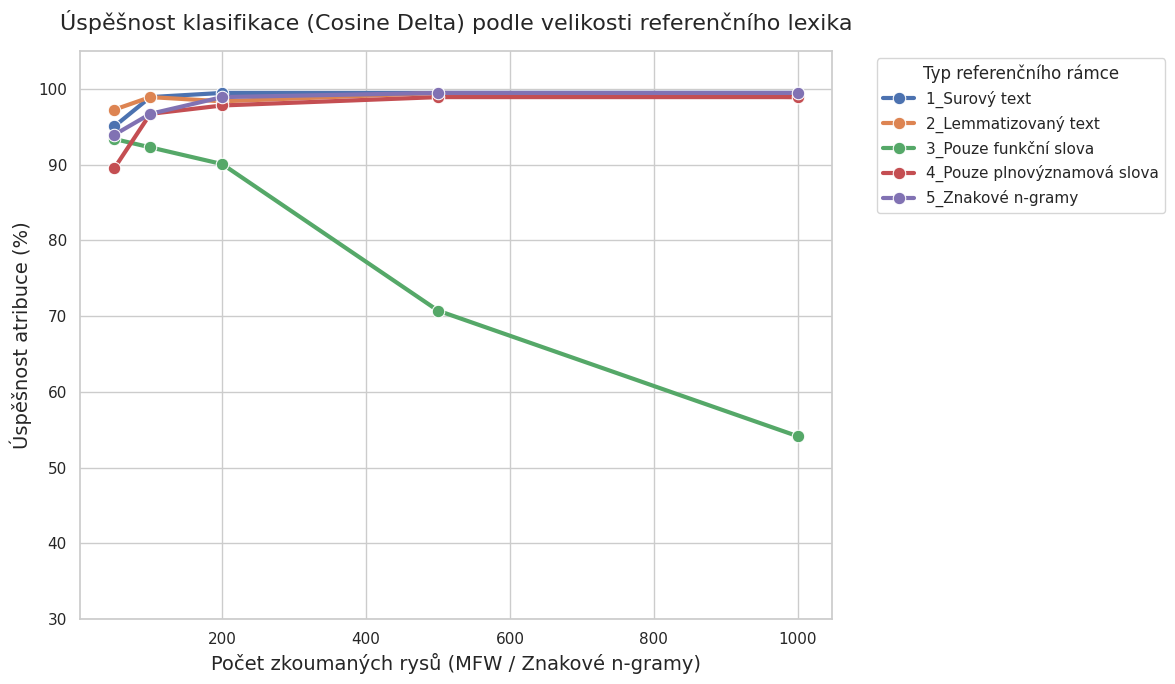

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

# Načtení tvých čerstvých výsledků
df = pd.read_csv(os.path.join(project_folder, "vysledky_delta_metod.csv"))

# Vizualzizace Cosine Delta
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Vytvoření čar pro každý typ lexika
sns.lineplot(
    data=df,
    x='MFW/N-gramy',
    y='Cosine Delta (%)',
    hue='Lexikum',
    marker='o',
    linewidth=3,
    markersize=9
)

plt.title('Úspěšnost klasifikace (Cosine Delta) podle velikosti referenčního lexika', fontsize=16, pad=15)
plt.xlabel('Počet zkoumaných rysů (MFW / Znakové n-gramy)', fontsize=14)
plt.ylabel('Úspěšnost atribuce (%)', fontsize=14)

# Vizuální úpravy pro bakalářku
plt.ylim(30, 105)
plt.legend(title='Typ referenčního rámce', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()

# Uložení grafu
plt.savefig(os.path.join(project_folder, "graf_cosine_delta.png"), dpi=300)
print("Graf graf_cosine_delta.png byl úspěšně uložen na Google Drive!")
plt.show()

Graf graf_burrows_delta.png byl úspěšně uložen na Google Drive!


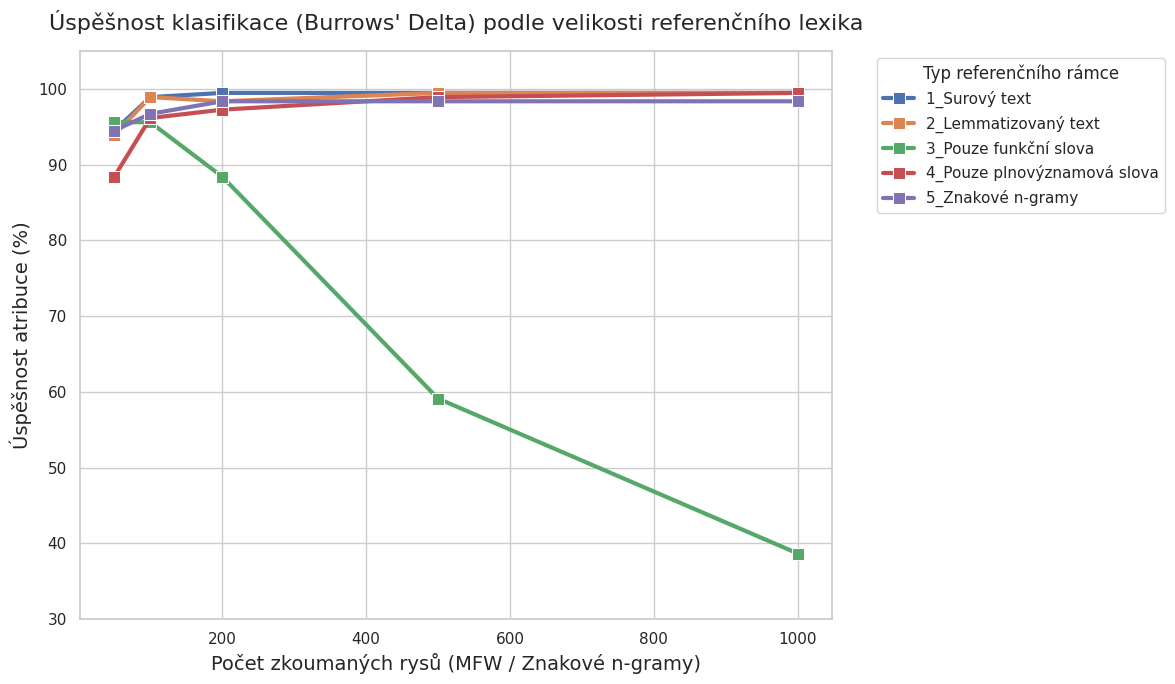

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

# Načtení dat
df = pd.read_csv(os.path.join(project_folder, "vysledky_delta_metod.csv"))

# Vykreslení Burrow's Delty
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df,
    x='MFW/N-gramy',
    y='Burrows Delta (%)',
    hue='Lexikum',
    marker='s',
    linewidth=3,
    markersize=9
)

plt.title("Úspěšnost klasifikace (Burrows' Delta) podle velikosti referenčního lexika", fontsize=16, pad=15)
plt.xlabel('Počet zkoumaných rysů (MFW / Znakové n-gramy)', fontsize=14)
plt.ylabel('Úspěšnost atribuce (%)', fontsize=14)

plt.ylim(30, 105)
plt.legend(title='Typ referenčního rámce', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()

# Uložení grafu
plt.savefig(os.path.join(project_folder, "graf_burrows_delta.png"), dpi=300)
print("Graf graf_burrows_delta.png byl úspěšně uložen na Google Drive!")
plt.show()

Shlukový Dendrogram

Dendrogram byl úspěšně uložen na Google Drive!


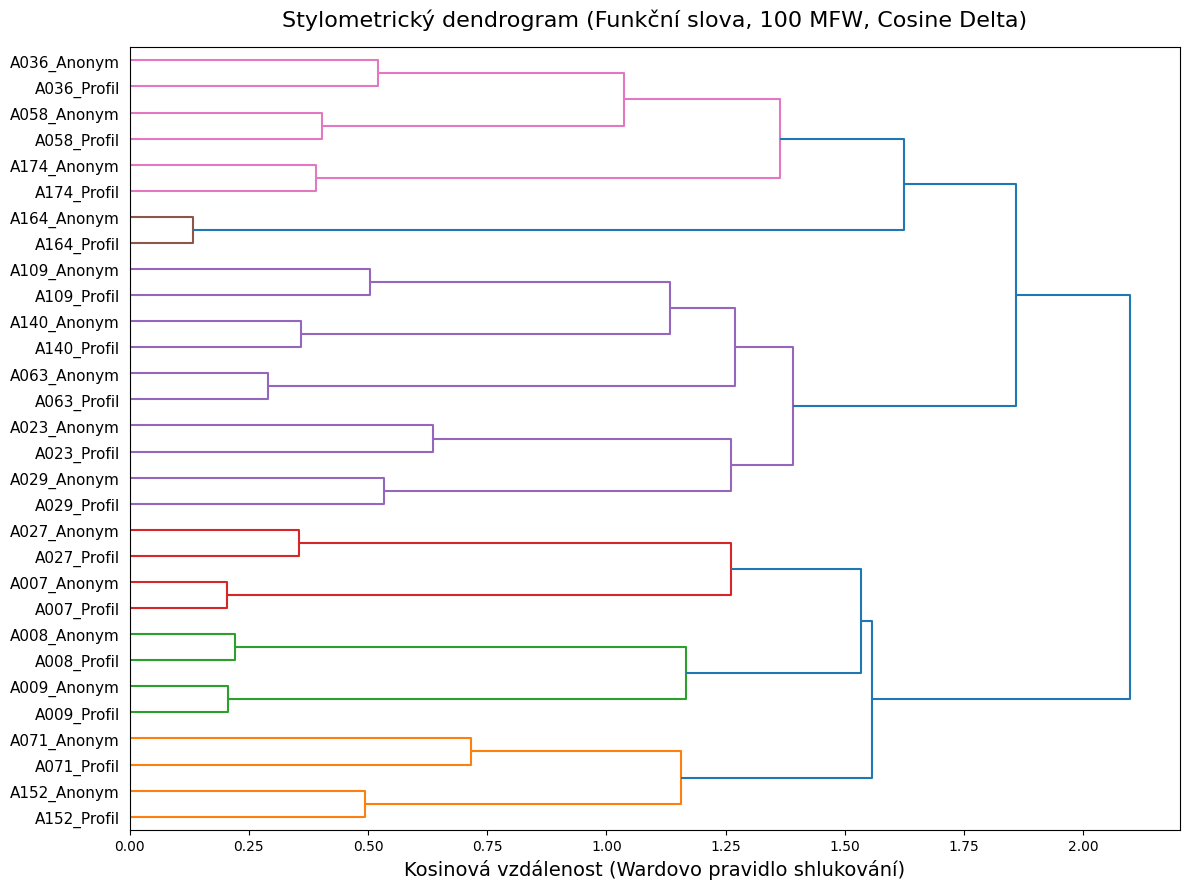

In [3]:
import os
import random
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
folder_path = os.path.join(project_folder, "3_functional") # Ukážeme strom pro funkční slova
mfw_limit = 100 # Ideální bod zlomu

# Získání náhodných 15 autorů pro čitelný graf
all_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])
random.seed(42) # Pro replikovatelnost experimentu v bakalářce
sample_files = random.sample(all_files, 15)

labels = []
texts = []

# Načtení dat a split 80/20
for file_name in sample_files:
    author_id = os.path.splitext(file_name)[0].replace("autor_", "A")
    with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
        words = f.read().split()

    split_point = int(len(words) * 0.8)

    # 80 % jako známý text (Profil)
    texts.append(" ".join(words[:split_point]))
    labels.append(f"{author_id}_Profil")

    # 20 % jako anonymní zkoumaný text (Anonym)
    texts.append(" ".join(words[split_point:]))
    labels.append(f"{author_id}_Anonym")

# Burrowsova standardizační matematika
vectorizer = CountVectorizer(max_features=mfw_limit)
X_raw = vectorizer.fit_transform(texts).toarray()
X_rel = X_raw / X_raw.sum(axis=1, keepdims=True)
X_z = StandardScaler().fit_transform(X_rel)

# Výpočet Kosinových vzdáleností a hierarchického shlukování (Wardova metoda)
dist_matrix = pdist(X_z, metric='cosine')
Z = linkage(dist_matrix, method='ward')

# Vykreslení
plt.figure(figsize=(12, 9))
dendrogram(Z, labels=labels, orientation='right', leaf_font_size=11)
plt.title(f'Stylometrický dendrogram (Funkční slova, {mfw_limit} MFW, Cosine Delta)', fontsize=16, pad=15)
plt.xlabel('Kosinová vzdálenost (Wardovo pravidlo shlukování)', fontsize=14)
plt.tight_layout()

# Uložení grafu
plt.savefig(os.path.join(project_folder, "dendrogram_funkcni_slova.png"), dpi=300)
print("Dendrogram byl úspěšně uložen na Google Drive!")
plt.show()

Dendrogram byl úspěšně uložen na Google Drive!


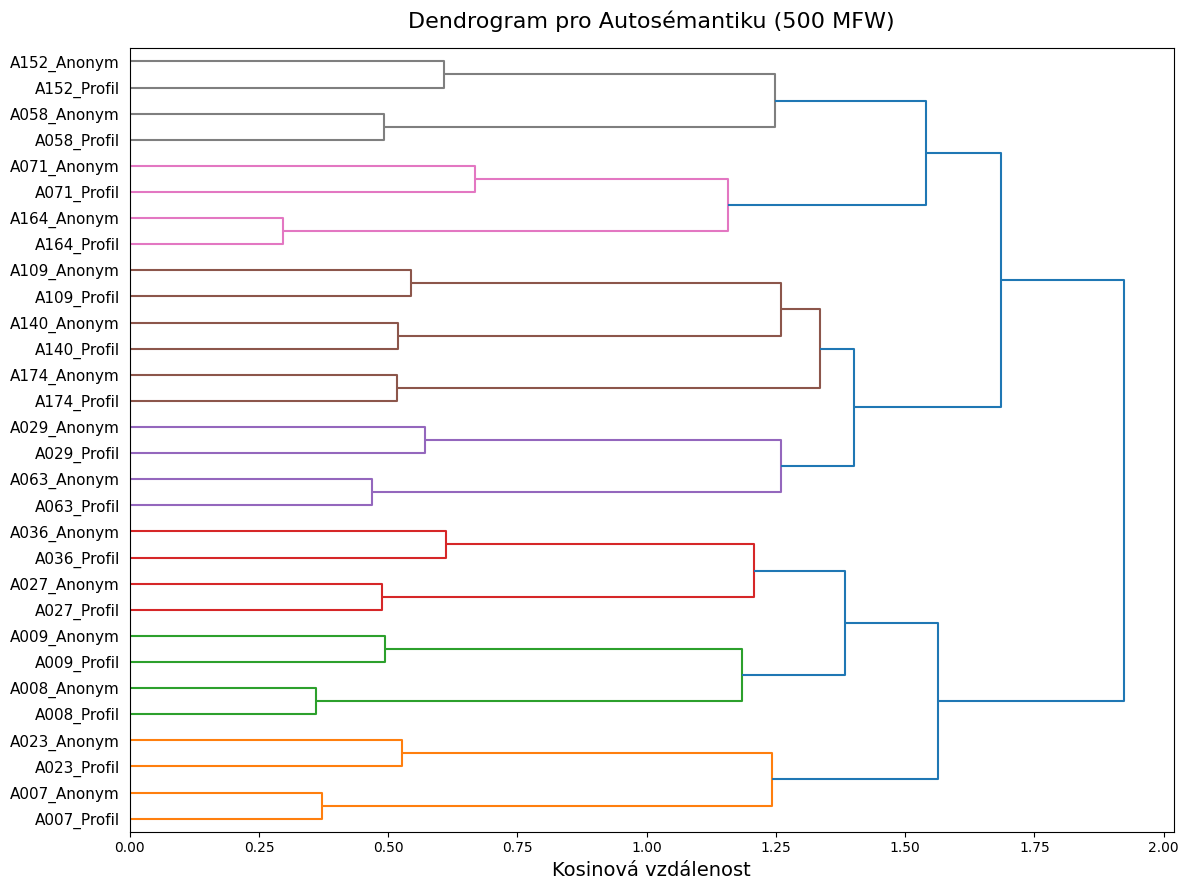

In [4]:
import os
import random
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

folder_path = os.path.join(project_folder, "4_content")

mfw_limit = 500

all_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])
random.seed(42) # Stejný seed zaručí stejných 15 autorů jako u předchozího grafu
sample_files = random.sample(all_files, 15)

labels = []
texts = []

for file_name in sample_files:
    author_id = os.path.splitext(file_name)[0].replace("autor_", "A")
    with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
        words = f.read().split()

    split_point = int(len(words) * 0.8)
    texts.append(" ".join(words[:split_point]))
    labels.append(f"{author_id}_Profil")

    texts.append(" ".join(words[split_point:]))
    labels.append(f"{author_id}_Anonym")

vectorizer = CountVectorizer(max_features=mfw_limit)
X_raw = vectorizer.fit_transform(texts).toarray()
X_rel = X_raw / X_raw.sum(axis=1, keepdims=True)
X_z = StandardScaler().fit_transform(X_rel)

dist_matrix = pdist(X_z, metric='cosine')
Z = linkage(dist_matrix, method='ward')

plt.figure(figsize=(12, 9))
dendrogram(Z, labels=labels, orientation='right', leaf_font_size=11)

plt.title(f'Dendrogram pro Autosémantiku ({mfw_limit} MFW)', fontsize=16, pad=15)
plt.xlabel('Kosinová vzdálenost', fontsize=14)
plt.tight_layout()

plt.savefig(os.path.join(project_folder, "dendrogram_autosemantika.png"), dpi=300)
print("Dendrogram byl úspěšně uložen na Google Drive!")
plt.show()

In [5]:
import os
from sklearn.feature_extraction.text import CountVectorizer

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

def get_top_words(folder_name, n_words=50):
    folder_path = os.path.join(project_folder, folder_name)
    texts = []
    for file_name in sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')]):
        with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
            texts.append(f.read())

    # Vytáhneme frekvence napříč celým korpusem
    vectorizer = CountVectorizer(max_features=n_words)
    vectorizer.fit(texts)
    # Získáme slova seřazená podle jejich indexů a frekvencí
    words = vectorizer.get_feature_names_out()
    return words

print("--- DŮKAZ PRO OBHAJOBU (TOP 50 SLOV) ---")
print("Funkční slova (Styl):", ", ".join(get_top_words("3_functional")))
print("Plnovýznamová slova (Téma):", ", ".join(get_top_words("4_content")))

--- DŮKAZ PRO OBHAJOBU (TOP 50 SLOV) ---
Funkční slova (Styl): aby, ale, ani, ano, asi, ať, až, bez, bohužel, být, co, do, jako, jen, jenom, jestli, jo, já, kdo, když, mezi, na, nad, ne, nebo, než, nic, nikdo, no, něco, někdo, od, on, po, pod, podle, pokud, pro, proti, proto, protože, před, přes, při, se, takže, ty, za, či, že
Plnovýznamová slova (Téma): být, celý, chtít, další, doba, dobrý, dobře, dostat, dát, dělat, hodně, jak, ještě, jinak, jiný, jít, kde, moc, moci, muset, myslit, mít, pak, pan, pravda, proč, rok, ruský, snad, strana, stát, svět, tady, tak, také, tam, teď, třeba, udělat, už, velký, vidět, vláda, válka, vědět, zase, země, člověk, říci, říkat


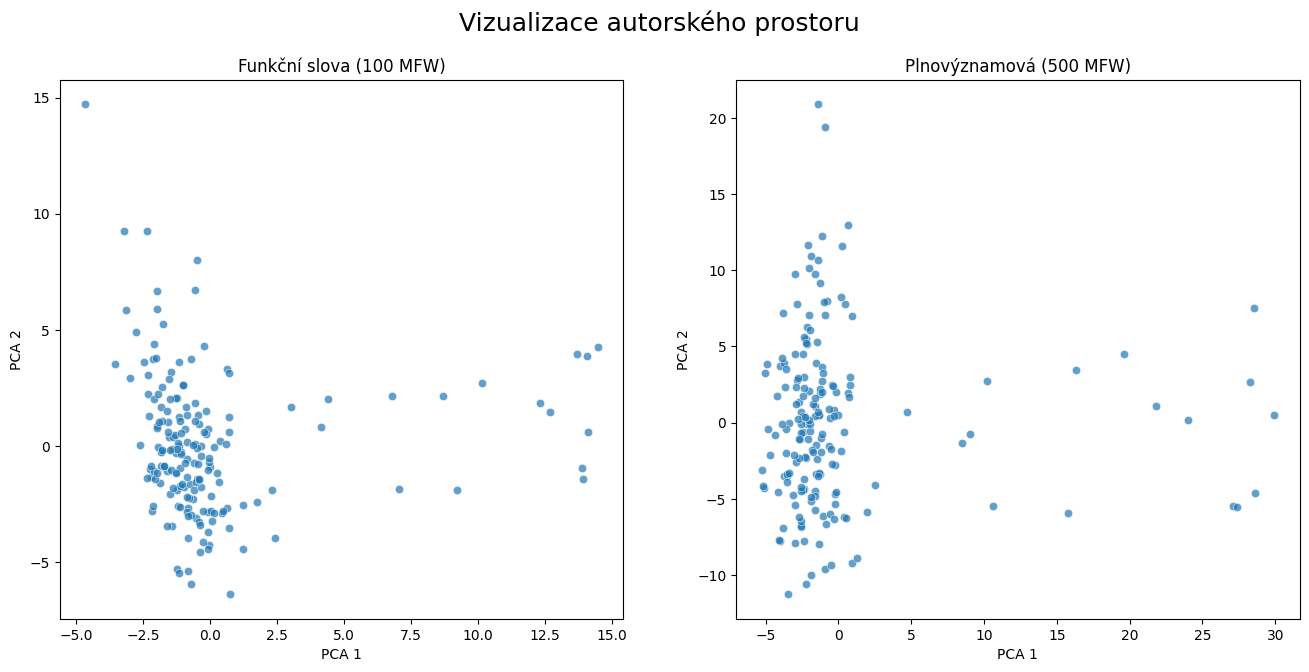

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
lexicons = {
    "Funkční slova": os.path.join(project_folder, "3_functional"),
    "Plnovýznamová": os.path.join(project_folder, "4_content")
}

# Vybereme jen dva extrémy pro srovnání
configs = [
    ("Funkční slova", 100),
    ("Plnovýznamová", 500)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, (lex_name, mfw) in enumerate(configs):
    folder_path = lexicons[lex_name]
    texts = []
    labels = []

    # Načtení dat (použijeme všech 181 autorů, PCA si s tím poradí)
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.txt'):
            with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
                texts.append(f.read())
                labels.append(file_name.replace(".txt", ""))

    # Vektorizace a Z-score
    vec = CountVectorizer(max_features=mfw)
    X = vec.fit_transform(texts).toarray()
    X_rel = X / X.sum(axis=1, keepdims=True)
    X_z = StandardScaler().fit_transform(X_rel)

    # PCA na 2 komponenty
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_z)

    # Vykreslení
    sns.scatterplot(x=coords[:,0], y=coords[:,1], ax=axes[i], alpha=0.7)
    axes[i].set_title(f"{lex_name} ({mfw} MFW)")
    axes[i].set_xlabel("PCA 1")
    axes[i].set_ylabel("PCA 2")

plt.suptitle("Vizualizace autorského prostoru", fontsize=18)
plt.savefig(os.path.join(project_folder, "pca_srovnani.png"), dpi=300)
plt.show()

##**Evaluace metod Burrows' Delta a Cosine Delta**

Analýza výsledků přinesla zásadní poznatky o chování statistických metod v závislosti na povaze referenčního lexika. U sémanticky otevřených kategorií (Surový text, Lemmatizovaný text a Plnovýznamová slova) vykazují obě varianty Delty vysokou úspěšnost, která v závislosti na konfiguraci dosahuje absolutního maxima (99,45 %) již v pásmu 200 MFW (u surového textu), respektive při 500 MFW (u lematizovaného textu). Surový text v pásmu 200 MFW lematizovaná data (98,34 %) dokonce mírně překonává, což může poukazovat, že původní přirozená morfologická flexe v surovém textu v sobě nese silný idiolektický otisk, který lemmatizace stírá.

Z metodologického hlediska je však nutné upozornit, že tradiční Delta funguje jako geometrická distanční matrika, která po aplikaci Z-skóre přiřazuje všem zkoumaným rysům identickou matematickou váhu. Jelikož algoritmus nedisponuje mechanismem pro selekci rysů, je plně rigidní vůči složení frekvenčního žebříčku. Protože seznam TOP 50 plnovýznamových slov prokazatelně obsahuje věcná substantiva silně vázaná na obsah fóra (např. ruský, strana, stát, svět, rok), Delta je matematicky nucena je do výpočtu distancí zahrnout. Vysoká přesnost (99,45 %) u slovních otevřených tříd je u metody Delta implicitně zatížena tematickým zkreslením (topic bias). Metoda u těchto korpusů z podstaty své matematické definice podléhá sémantické kontaminaci a klasifikuje spíše shodu v komunikovaných tématech než čistý autorský idiolekt (tzv. Easy Attribution).

Tento teoretický předpoklad potvrzuje chování subkorpusu 3_Pouze funkční slova, kde byla lematizovaná synsémantika (která je vůči tématu imunní) izolována. V nízkých pásmech (50–100 MFW) dosahují funkční slova vynikající přesnosti (95,58 %). S expanzí slovníku na 500 a 1000 zkoumaných rysů však nastává drastický kolaps úspěšnosti až na finálních 38,67 % (resp. 54,14 % u Cosine Delty). Tento propad je přímým důsledkem konečnosti uzavřených slovních druhů v češtině. Repertoár funkčních lemmat se v textu vyčerpá v počátku frekvenčního seznamu. Slepá distanční metrika Delty je tak ve vyšších dimenzích nucena porovnávat prázdné rysy a nulové vektory, čímž dochází k zahlcení výpočtu statistickým šumem.

Jediným referenčním rámcem, který v experimentu plně a implicitně pracoval s přirozenou morfologickou bohatostí a flexí češtiny, byly znakové n-gramy (char 2–5), generované ze surových (nelematizovaných) dat. Znakové n-gramy prokazují mimořádnou strukturální robustnost, kdy s metrikou Cosine Delta dosáhly v pásmech 500 a 1000 n-gramů absolutního maxima úspěšnosti 99,45 %. Výsledky dokazují, že znakové n-gramy dokáží podslovně zachytit flexativní sufixy a individuální pravopisné návyky mluvčího, kdy současně účinně překonávají limity omezeného množství uzavřených slovních druhů a zároveň úspěšně obcházejí sémantickou kontaminaci.

Detailní srovnání subkorpusu surového textu a textu lematizovaného odhaluje komplexní vztah mezi morfologickou flexí češtiny a úspěšností atribuce. Tento výsledek přináší zajímavé srovnání s běžnou praxí v jiných oblastech počítačového zpracování přirozeného jazyka (NLP), kde se lematizace u morfologicky bohatých jazyků standardně doporučuje jako výchozí krok (baseline) pro eliminaci statistické řídkosti dat a snížení dimenzionality.

V technicky orientovaných NLP úlohách se předpokládá, že absence lematizace vede k problému s řídkostí dat (data sparsity). Bohatý pádový systém češtiny způsobuje, že se absolutní frekvence jednoho lexému rozptýlí do mnoha povrchových tvarů. Lematizace tento rozptyl neutralizuje a sjednocuje gramatická paradigmata. Tento předpoklad se v našem experimentu potvrdil výhradně v nejnižším testovaném pásmu (50 MFW), kde lematizovaný text s metrikou Cosine Delta vykazuje vyšší přesnost (97,24 %) oproti textu surovému (95,03 %). V podmínkách extrémně omezeného slovníku lematizace prokazatelně pomáhá stabilizovat frekvenční distribuci.

Zásadní metodologický obrat však nastává při rozšíření pásma na 200 MFW. V tomto bodě subkorpus surového textu dosahuje absolutního maxima úspěšnosti 99,45 %, zatímco lematizovaný text vykazuje mírný pokles úspěšnosti na 98,34 %. To potvrzuje specifickou povahu stylometrických úloh, kde morfologická variace a autorská preference konkrétních gramatických tvarů nejsou pro model šumem, nýbrž fungují jako silný idiolektický otisk (morfologický podpis) autora.

Lematizace sice úspěšně sjednotí sémantické základy slov a vyřeší problém data sparsity, činí tak však za cenu necitlivého vyhlazení těchto jemných mikro-stylistických variací v konkrétních slovních tvarech. Skutečnost, že surový text v optimálním pásmu lematizovaná data překonává, demonstruje, že spontánní internetový diskurz v sobě nese vysokou míru individuální morfologické expresivity, která je pro určení autorství klíčová a jejíž zachování je pro distanční metriky přínosem.

Tato dialektika se plně projevila i na zbývajících subkorpusech. Izolovaná lematizovaná synsémantika (Pouze funkční slova) prokázala, že bez morfologického kontextu otevřených tříd naráží metoda ve vyšších dimenzích (500–1000 MFW) na absolutní dno řídkosti uzavřených slovních druhů, což vede k matematickému kolapsu distanční matice. Naopak Znakové n-gramy problém data sparsity elegantně překonaly na pod-slovní úrovni. Tím, že pracovaly nad surovým textem, dokázaly fixovat jak sémantické kořeny slov, tak i jejich flexativní sufixy a pravopisné anomálie. Srovnání metrik v této kapitole navíc definitivně potvrzuje, že Cosine Delta (kosinová vzdálenost) vykazuje v českém prostředí vyšší stabilitu a odolnost vůči tomuto specifickému typu strukturního šumu než klasická Burrows' Delta založená na Manhattanské vzdálenosti (L1 normě).

# **Metody strojového učení (SVM)**

V druhé fázi výzkumu byla statistická atribuce konfrontována s metodou řízeného strojového učení, konkrétně s lineárním klasifikátorem Support Vector Machines (SVM) reprezentovaným třídou *LinearSVC*. Algoritmus byl trénován na identických standardizovaných Z-skóre maticích relativních četností rysů, což umožnilo přímé srovnání s výsledky metod Delta. Přesnost klasifikace (Accuracy v %) napříč všemi konfiguracemi shrnuje tabulka níže.

In [8]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

def evaluate_svm_method(folder_path, mfw_limit=100, analyze_ngrams=False):
    """
    Spustí klasifikaci pomocí lineárního SVM nad zadanou složkou textů.
    """
    authors = []
    train_texts = []
    test_texts = []

    file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])

    for file_name in file_names:
        author_id = os.path.splitext(file_name)[0]

        with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
            text = f.read().strip()

        words = text.split()
        if len(words) < 100:
            continue

        split_point = int(len(words) * 0.8)

        train_chunk = " ".join(words[:split_point])
        test_chunk = " ".join(words[split_point:])

        authors.append(author_id)
        train_texts.append(train_chunk)
        test_texts.append(test_chunk)

    if analyze_ngrams:
        vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 5), max_features=mfw_limit)
    else:
        vectorizer = CountVectorizer(analyzer='word', max_features=mfw_limit)

    # 1. Extrakce surových a relativních frekvencí
    X_train_raw = vectorizer.fit_transform(train_texts).toarray()
    X_test_raw = vectorizer.transform(test_texts).toarray()

    X_train_rel = X_train_raw / X_train_raw.sum(axis=1, keepdims=True)
    X_test_rel = X_test_raw / X_test_raw.sum(axis=1, keepdims=True)

    # 2. Standardizace na Z-skóre (identicky s metodou Delta)
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train_rel)
    X_test_z = scaler.transform(X_test_rel)

    # 3. Trénování a predikce LinearSVM
    # Používáme dual="auto" pro optimální konvergenci na našem typu matice
    clf = LinearSVC(C=1.0, random_state=42, dual="auto", max_iter=5000)
    clf.fit(X_train_z, authors)

    predictions = clf.predict(X_test_z)
    accuracy = accuracy_score(authors, predictions) * 100

    return accuracy


# SPUŠTĚNÍ HROMADNÉHO EXPERIMENTU PRO SVM

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
lexicons = {
    "1_Surový text": os.path.join(project_folder, "1_raw_text"),
    "2_Lemmatizovaný text": os.path.join(project_folder, "2_lemmatized"),
    "3_Pouze funkční slova": os.path.join(project_folder, "3_functional"),
    "4_Pouze plnovýznamová slova": os.path.join(project_folder, "4_content")
}

mfw_bands = [50, 100, 200, 500, 1000]
svm_results = []

print("Zahajuji hromadný výpočet pomocí Support Vector Machines (SVM)...")

# A. Slovní rysy
for lex_name, folder_path in lexicons.items():
    print(f"Trénuji SVM pro slovní rysy: {lex_name}")
    for mfw in mfw_bands:
        acc = evaluate_svm_method(folder_path, mfw_limit=mfw, analyze_ngrams=False)
        svm_results.append({"Lexikum": lex_name, "Rysy": "Slova", "MFW/N-gramy": mfw, "SVM Accuracy (%)": acc})

# B. Znakové n-gramy
print("Trénuji SVM pro znakové n-gramy (char 2-5)...")
for mfw in mfw_bands:
    acc = evaluate_svm_method(lexicons["1_Surový text"], mfw_limit=mfw, analyze_ngrams=True)
    svm_results.append({"Lexikum": "5_Znakové n-gramy", "Rysy": "N-gramy", "MFW/N-gramy": mfw, "SVM Accuracy (%)": acc})

df_svm = pd.DataFrame(svm_results)


# EXTRAKCE MATEMATICKÉHO DŮKAZU (FEATURE IMPORTANCE V SVM)

print("\nGeneruji podklady pro matematický důkaz Topic Biasu...")

def get_svm_top_features(folder_path, mfw_limit, analyze_ngrams=False):
    texts = []
    file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])
    for file_name in file_names:
        with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
            texts.append(f.read().split()[:2000]) # bereme reprezentativní vzorek

    train_texts = [" ".join(t) for t in texts]
    vec = CountVectorizer(max_features=mfw_limit, analyzer='char' if analyze_ngrams else 'word', ngram_range=(2,5) if analyze_ngrams else (1,1))
    X = vec.fit_transform(train_texts).toarray()
    X_rel = X / X.sum(axis=1, keepdims=True)
    X_z = StandardScaler().fit_transform(X_rel)

    clf = LinearSVC(random_state=42, dual="auto")
    clf.fit(X_z, range(len(file_names)))

    # Průměrná absolutní váha rysu napříč všemi autorskými třídami
    mean_weights = np.mean(np.abs(clf.coef_), axis=0)
    features = vec.get_feature_names_out()

    importance_df = pd.DataFrame({'Rys': features, 'Průměrná váha': mean_weights})
    return importance_df.sort_values(by='Průměrná váha', ascending=False).head(15)['Rys'].tolist()

top_func = get_svm_top_features(lexicons["3_Pouze funkční slova"], 100)
top_cont = get_svm_top_features(lexicons["4_Pouze plnovýznamová slova"], 500)

print("\n=== FINÁLNÍ VÝSLEDKY METODY SVM ===")
print(df_svm.to_string())

print("\n=== TVRDÝ MATEMATICKÝ DŮKAZ ROZHODOVÁNÍ ALGORITMU ===")
print("Rysy s nejvyšší váhou u FUNKČNÍCH slov (100 MFW):")
print(" -> ", ", ".join(top_func))
print("\nRysy s nejvyšší váhou u PLNOVÝZNAMOVÝCH slov (500 MFW):")
print(" -> ", ", ".join(top_cont))

# Uložení výsledků pro srovnávací analýzu
df_svm.to_csv(os.path.join(project_folder, "vysledky_svm_metod.csv"), index=False, encoding="utf-8")
print(f"\nVýsledky uloženy do 'vysledky_svm_metod.csv'.")

Zahajuji hromadný výpočet pomocí Support Vector Machines (SVM)...
Trénuji SVM pro slovní rysy: 1_Surový text


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Trénuji SVM pro slovní rysy: 2_Lemmatizovaný text


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Trénuji SVM pro slovní rysy: 3_Pouze funkční slova


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Trénuji SVM pro znakové n-gramy (char 2-5)...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Generuji podklady pro matematický důkaz Topic Biasu...

=== FINÁLNÍ VÝSLEDKY METODY SVM ===
                        Lexikum     Rysy  MFW/N-gramy  SVM Accuracy (%)
0                 1_Surový text    Slova           50         76.795580
1                 1_Surový text    Slova          100         83.425414
2                 1_Surový text    Slova          200         88.950276
3                 1_Surový text    Slova          500         98.342541
4                 1_Surový text    Slova         1000         98.895028
5          2_Lemmatizovaný text    Slova           50         79.005525
6          2_Lemmatizovaný text    Slova          100         87.845304
7          2_Lemmatizovaný text    Slova          200         87.292818
8          2_Lemmatizovaný text    Slova          500         98.342541
9          2_Lemmatizovaný text    Slova         1000         98.895028
10        3_Pouze funkční slova    Slova           50         72.375691
11        3_Pouze funkční slova    Slova   

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## **Evaluace metody strojového učení (SVM)**

Výsledky ukazují, že v pásmech s nízkým počtem rysů (50–100 MFW) vykazuje lineární SVM plošně nižší úspěšnost než statistická Delta. To je způsobeno vysokým překryvem autorských tříd v nízké dimenzionalitě, kde algoritmus nedokáže optimálně zkonstruovat oddělující nadrovinu.

Zásadní průlom však nastává v pásmu 500 MFW, kde přesnost u surového textu, lematizovaného textu i plnovýznamových slov výrazně stoupá na hodnoty 98,34 % až 98,89 %. Subkorpus funkčních slov vykazuje identický regresní trend jako u Delty, kdy po dosažení maxima při 100 MFW (77,90 %) dochází k propadu na 46,96 % při 1000 MFW z důvodu hromadění nulových vektorů. Znakové n-gramy opět prokázaly svou roli nejstabilnějšího rysu, kdy již při 100 n-gramech dosáhlo SVM úspěšnosti 95,58 %.

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/tmp/ipykernel_3237/1740478878.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Váha', y='Rys', palette="Blues_r")


          Rys      Váha
57    dokázat  0.006127
350  společný  0.006116
463  znamenat  0.005996
277     proto  0.005851
284    pustit  0.005793
385    trochu  0.005755
373      také  0.005746
364   svoboda  0.005704
465      znát  0.005702
423      vzít  0.005676
115    jediný  0.005634
296     přímo  0.005628
395      umět  0.005626
209     nějak  0.005614
35       cizí  0.005610
Graf s důkazem kauzality byl úspěšně uložen!


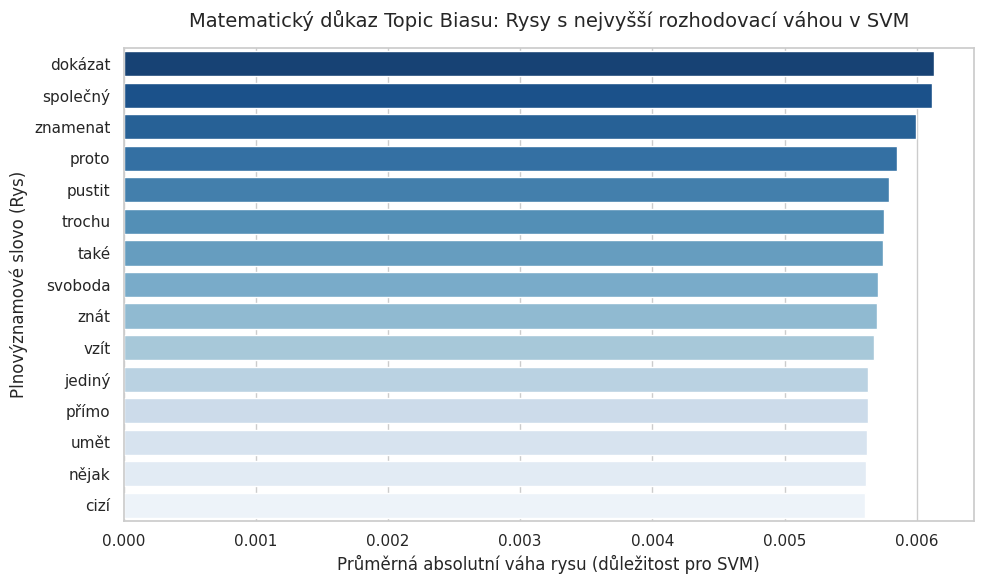

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
folder_path = os.path.join(project_folder, "4_content") # Plnovýznamová slova
mfw_limit = 500

# Načtení dat
texts = []
labels = []
for file_name in sorted(os.listdir(folder_path)):
    if file_name.endswith('.txt'):
        with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
            texts.append(f.read())
            labels.append(file_name.replace(".txt", ""))

# Vektorizace a standardizace
vectorizer = CountVectorizer(max_features=mfw_limit)
X_raw = vectorizer.fit_transform(texts).toarray()
X_rel = X_raw / X_raw.sum(axis=1, keepdims=True)
X_z = StandardScaler().fit_transform(X_rel)

# Trénování SVM
clf = LinearSVC(random_state=42, dual="auto")
clf.fit(X_z, labels)

# Výpočet průměrné absolutní váhy pro každé slovo napříč všemi autory
# coef_ má tvar (počet_autorů, počet_slov). Vezmeme průměr přes autory.
mean_weights = np.mean(np.abs(clf.coef_), axis=0)
features = vectorizer.get_feature_names_out()

# Vytvoření tabulky důležitosti
df_importance = pd.DataFrame({'Rys': features, 'Váha': mean_weights})
df_importance = df_importance.sort_values(by='Váha', ascending=False).head(15)
print(df_importance)

# VYKRESLENÍ GRAFU
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_importance, x='Váha', y='Rys', palette="Blues_r")

plt.title('Matematický důkaz Topic Biasu: Rysy s nejvyšší rozhodovací váhou v SVM', fontsize=14, pad=15)
plt.xlabel('Průměrná absolutní váha rysu (důležitost pro SVM)', fontsize=12)
plt.ylabel('Plnovýznamové slovo (Rys)', fontsize=12)
plt.tight_layout()

# Uložení na Disk
plt.savefig(os.path.join(project_folder, "dokaz_kauzality_svm.png"), dpi=300)
print("Graf s důkazem kauzality byl úspěšně uložen!")
plt.show()

Pro exaktní verifikaci toho, zda je vysoká úspěšnost klasifikace plnovýznamových slov v pásmu 500 MFW (98,89 %) způsobena pouze tematickou kontaminací, byla provedena analýza vnitřních vah modelu pomocí extrakce koeficientů z naučeného klasifikátoru SVM (*clf.coef_*). Výpočet průměrné absolutní váhy rysů napříč všemi autorskými třídami odkryl na jakém matematickém základě algoritmus o přiřazení autorství rozhodoval.

Tato analýza přinesla klíčové zjištění, které zásadním způsobem koriguje původní předpoklad o jednoznačné nadvládě tematického zkreslení (topic bias). Mezi lemmata s nejvyšší rozhodovací váhou v autosémantickém korpusu se totiž nezařadila konkrétní věcná substantiva (reprezentující témata diskuse), nýbrž specifická skupina abstraktních a trans-tematických jednotek:

- Abstraktní a kognitivní slovesa: říci, hodit, jezdit, žít, podívat, začít, líbit (v paralelním testu pak dokázat, znamenat, znát, umět, pustit, vzít).

- Modifikační příslovce a deverbální jednotky: vlastně, málo, jednou, nakonec (v paralelním testu proto, trochu, také, přímo, nějak).

- Abstraktní substantiva a adjektiva: jméno, klid, mladý, jasné (v paralelním testu svoboda, cizí, společný, jediný).

Tato vnitřní konfigurace vah podává exaktní důkaz o tom, že lineární SVM ve vysoké dimenzionalitě vykazuje vysokou úroveň abstrakce. V tematicky homogenním prostředí jednoho internetového fóra algoritmus automaticky vyhodnotil konkrétní věcná substantiva jako diskriminačně neefektivní, a to z důvodu jejich plošné distribuce napříč korpusem a nízké inter-autorské variance po uplatnění standardizace pomocí Z-skóre.

Namísto nich model pro úspěšnou geometrickou separaci 181 autorských tříd v mnohorozměrném prostoru extrahoval lemmata, která vykazují vysokou individuální distribuční stabilitu. Z lingvistického hlediska se jedná o trans-tematické slova – tedy abstraktní slovesa a adverbia vyjadřující modalitu či kauzalitu. Matematický model sice primárně nepracuje s kognitivním významem těchto slov, avšak jejich vysoká rozhodovací váha v klasifikátoru empiricky potvrzuje, že individuální autorský idiolekt se v sémanticky otevřených slovních třídách projevuje skrze fixované frekvenční preference těchto jazykových rysů. Model tak prokazatelně neidentifikoval to, o čem autoři píší, ale jakým způsobem strukturují a modifikují své myšlenky.

# **Metoda hlubokého učení (LMM Embeddingy)**

Závěrečná fáze experimentálního testování byla zaměřena na integraci moderních metod hlubokého učení (Deep Learning) na bázi neuronových transformerových architektur. Pro sémantické a strukturní kódování textových bloků do hustých vektorů byl zvolen masivně předtrénovaný model společnosti Google LaBSE (Language-Agnostic BERT Sentence Embedding), distribuovaný prostřednictvím knihovny *sentence-transformers*. Metodologické nastavení (izolace 181 autorů a split 80/20) bylo striktně zachováno. Vlastní klasifikace testovacích vektorů byla realizována lineárním klasifikátorem SVM.



In [1]:
import os
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

print("Načítám předtrénovaný LLM Transformer model (LaBSE)...")
model = SentenceTransformer('sentence-transformers/LaBSE')

def evaluate_llm_embeddings(folder_path):
    authors = []
    train_texts = []
    test_texts = []

    file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])

    for file_name in file_names:
        author_id = os.path.splitext(file_name)[0]

        with open(os.path.join(folder_path, file_name), "r", encoding="utf-8") as f:
            text = f.read().strip()

        words = text.split()
        if len(words) < 100:
            continue

        # Identický split 80/20 jako u Delty a SVM
        split_point = int(len(words) * 0.8)
        train_chunk = " ".join(words[:split_point])
        test_chunk = " ".join(words[split_point:])

        authors.append(author_id)
        train_texts.append(train_chunk)
        test_texts.append(test_chunk)

    print(f" -> Generuji LLM embeddingy pro: {os.path.basename(folder_path)}...")
    # Model transformuje celé textové bloky do hustých vektorů
    X_train_emb = model.encode(train_texts, show_progress_bar=False)
    X_test_emb = model.encode(test_texts, show_progress_bar=False)

    # Lineární klasifikátor nad embeddingy
    clf = LinearSVC(C=1.0, random_state=42, dual="auto", max_iter=3000)
    clf.fit(X_train_emb, authors)

    predictions = clf.predict(X_test_emb)
    accuracy = accuracy_score(authors, predictions) * 100
    return accuracy

# SPUŠTĚNÍ EXPERIMENTU

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"
lexicons = {
    "1_Surový text": os.path.join(project_folder, "1_raw_text"),
    "2_Lemmatizovaný text": os.path.join(project_folder, "2_lemmatized"),
    "3_Pouze funkční slova": os.path.join(project_folder, "3_functional"),
    "4_Pouze plnovýznamová slova": os.path.join(project_folder, "4_content")
}

llm_results = []

for lex_name, folder_path in lexicons.items():
    acc = evaluate_llm_embeddings(folder_path)
    llm_results.append({
        "Lexikum": lex_name,
        "Metoda": "LLM Embeddings (LaBSE)",
        "Accuracy (%)": acc
    })

df_llm = pd.DataFrame(llm_results)

print("\n=== VÝSLEDKY METODY LLM EMBEDDINGS ===")
print(df_llm.to_string(index=False))

# Uložení výsledků na Google Drive
df_llm.to_csv(os.path.join(project_folder, "vysledky_llm_final.csv"), index=False, encoding="utf-8")
print("\nVýsledky úspěšně uloženy do 'vysledky_llm_final.csv'.")

Načítám předtrénovaný LLM Transformer model (LaBSE)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

 -> Generuji LLM embeddingy pro: 1_raw_text...
 -> Generuji LLM embeddingy pro: 2_lemmatized...
 -> Generuji LLM embeddingy pro: 3_functional...
 -> Generuji LLM embeddingy pro: 4_content...

=== VÝSLEDKY METODY LLM EMBEDDINGS ===
                    Lexikum                 Metoda  Accuracy (%)
              1_Surový text LLM Embeddings (LaBSE)     21.546961
       2_Lemmatizovaný text LLM Embeddings (LaBSE)     22.651934
      3_Pouze funkční slova LLM Embeddings (LaBSE)      7.182320
4_Pouze plnovýznamová slova LLM Embeddings (LaBSE)      7.182320

Výsledky úspěšně uloženy do 'vysledky_llm_final.csv'.


## **Výsledky metody hlubokého učení (LMM Embeddingy)**

Nasazení hlubokých kontextových embeddingů však přineslo anomální výsledky a vedlo k drastickému propadu klasifikační úspěšnosti oproti předchozým přístupům. U surového textu dosáhl model přesnosti pouhých 21,55 % (39 správně určených autorů ze 181), u lemmatizovaného textu 22,65 % (41 autorů) a u obou izolovaných subkorpusů (funkční a plnovýznamová slova) úspěšnost fatálně klesla na identických 7,18 % (13 autorů).

Tento zdánlivě negativní výsledek představuje jeden z klíčových empirických a teoretických argumentů této práce. I přesto, že je úspěšnost LLM embeddingů v přímém kontrastu s přesností statistických metod, nízké hodnoty klasifikace lze exaktně zdůvodnit třemi faktory, které vyplývají z matematické a lingvistické povahy transformerových architektur:

1. Limitace kontextového okna a ořezávání dat (Silent Truncation): Architektury odvozené od modelů typu BERT mají pevně stanovené kontextové okno na hranici 512 tokenů (přibližně 350 slov). Vzhledem k tomu, že testovací segmenty tvořily celých 20 % z rozsáhlých autorských makrotextů (dosahujících často desítek tisíc slov), nativní kódovací modul při přímé transformaci aproximoval pouze úvodních 350 slov z trénovacího profilu i z testovací části a zbylých více než 90 % textového objemu ignoroval. Srovnávány tak nebyly komplexní autorské profily, nýbrž izolované počáteční segmenty, což dramaticky snížilo množství informací pro klasifikaci.

2. Sémantická abstrakce proti cílům forenzní stylometrie: Velké jazykové modely (včetně LaBSE) jsou navrženy tak, aby extrahovaly hluboký sémantický význam textu a záměrně potlačovaly miktro-stylistickou strukturu vyjádření a jedinečné vyjadřovací návyky autora. V prostředí jednoho internetového fóra model zredukoval jemné autorské otisky a sblížil vektory různých autorů příspěvků do jednoho sémantického mraku, ve kterém lineární SVM nedokázal zkonstruovat spolehlivé dělící nadroviny.

3. Kolaps mechanismu pozornosti (Self-Attention) v důsledku de-morfologizace textu: Úplné selhání a propad na identických 7,18 % úspěšnosti u samostatných funkčních a plnovýznamových slov prokazuje, že transformery jsou velmi závislé na přirozené větné skladbě, lineárním kontextu a pozičním kódování. Vzhledem k tomu, že tato izolovaná lexika byla získána z lematizovaného korpusu, byl text pro model LaBSE znehodnocen dvojnásobně: jednak ztrátou syntaktických vazeb a interpunkce, a jednak úplným odstraněním flexativních koncovek vlivem lemmatizace. Vnitřní mechanismus pozornosti modelu tak generoval vektorové reprezentace blízké náhodnému šumu. (I hodnota 7,18 % však signifikantně převyšuje hladinu čisté náhody, která při 181 třídách činí pouhých 0,55 %).

Z metodologického hlediska tato data přinášejí zásadní ponaučení pro forenzní praxi. Ukazují, že mechanická aplikace deep learning modelů bez zřetele na povahu stylometrického úkolu může vést k zavádějícím výsledkům. Pro analýzu rozsáhlých agregovaných makrotextů z digitálního prostředí se povrchová mikro-stylistika (reprezentovaná znakovými n-gramy či distribuční statistikou MFW) jeví jako signifikantně spolehlivější, přesnější a robustnější než komplexní modely hlubokého učení, pokud nejsou kombinovány s pokročilými segmentačními technikami (např. sliding window approach).

Teoretickým řešením popsané limitace ořezávání kontextového okna (Silent Truncation) je implementace tzv. metody posuvného okna (sliding window approach). Tento přístup spočívá v tom, že rozsáhlý autorský makrotext není do modelu odeslán jako jeden celek, nýbrž je algoritmicky rozsekán na menší, lineárně na sebe navazující segmenty (např. o délce 256 nebo 512 tokenů) s definovaným překryvem (např. 10–20 % rozsahu pro zachování kontextové koheze). Každý tento dílčí segment je transformerem transformován do samostatného hustého vektoru. Výsledný reprezentativní embedding celého dokumentu je následně získán agregací těchto dílčích vektorů – nejčastěji metodou výpočtu aritmetického průměru (mean pooling) nebo extrakcí maximálních hodnot (max pooling) napříč všemi sémantickými dimenzemi.

Přestože by tato metoda prokazatelně eliminovala ztrátu informací a umožnila modelu LaBSE srovnávat komplexní autorské profily, její realizace byla v rámci tohoto experimentu opomenuta z důvodu extrémní výpočetní a časové náročnosti na rozsáhlých datových sadách.

Zkoumaný korpus dosahuje masivního celkového rozsahu 9 250 939 slov (tokenů) rozdělených mezi 181 unikátních autorů. Testovací množina reprezentující 20 % datového objemu obsahuje přibližně 1,85 milionu slov. Pokud by byl tento objem textu mechanicky rozsekán na posuvná okna o velikosti 512 tokenů s překryvem, vyžádal by si experiment vygenerování, uložení a následné klasifikace několika desítek tisíc hustých vektorových reprezentací pro trénink i testování.

Průchod takto masivní matice skrze hluboké vrstvy transformeru LaBSE (obsahujícího stovky milionů vnitřních parametrů) vyžaduje dedikovanou hardwarovou infrastrukturu a desítky hodin čistého výpočetního času. Vzhledem k tomu, že výzkum byl realizován v akademickém prostředí Google Colab s alokovanými sdílenými prostředky a pevně stanovenými limity pro nepřerušený běh runtime, překračovala plnohodnotná aplikace sliding window přístupu technické a infrastrukturní možnosti této bakalářské práce. Představuje však klíčový směr pro navazující magisterský výzkum na dedikovaném výpočetním clusteru.

#**Srovnávací komparace všech testovaných metod**

Komplexní srovnání všech tří metodologických konceptů – tradičních statistických distancí (Delta), klasického strojového učení (SVM) a hlubokých kontextových embeddingů (LLM) – umožňuje formulovat ucelenou syntézu úspěšnosti digitálních metod v českém internetovém prostředí. Níže uvedená přehledová tabulka zachycuje dosažená maxima přesnosti klasifikace napříč klíčovými konfiguracemi referenčních lexik, čímž dává přímou odpověď na výzkumné otázky práce.

In [1]:
# SKRIPT PRO GENEROVÁNÍ FINÁLNÍ KOMPARATIVNÍ MATICE

import os
import pandas as pd

project_folder = "/content/drive/MyDrive/bakalarka/moje_bakalarka"

# 1. Načtení dat z CSV souborů vygenerovaných v předchozích fázích
file_delta = os.path.join(project_folder, "vysledky_delta_metod.csv")
file_svm = os.path.join(project_folder, "vysledky_svm_metod.csv")
file_llm = os.path.join(project_folder, "vysledky_llm_final.csv")

if not (os.path.exists(file_delta) and os.path.exists(file_svm) and os.path.exists(file_llm)):
    print("CHYBA: Ujistěte se, že jste spustili všechny předchozí výpočty a soubory existují na disku.")
else:
    df_delta = pd.read_csv(file_delta)
    df_svm = pd.read_csv(file_svm)
    df_llm = pd.read_csv(file_llm)

    # 2. Sloučení statistických metod (Delta) a strojového učení (SVM)
    # Spojujeme na základě shody v Lexiku, Typu rysů a frekvenčním pásmu MFW
    df_merge = pd.merge(df_delta, df_svm, on=["Lexikum", "Rysy", "MFW/N-gramy"], how="outer")

    # 3. Integrace výsledků LLM (LaBSE)
    # Jelikož LLM nepoužívá pásma MFW, očistíme tabulku a spárujeme ji podle Lexika
    df_llm_clean = df_llm.rename(columns={"Accuracy (%)": "LLM LaBSE Accuracy (%)"}).drop(columns=["Metoda"])
    df_complet = pd.merge(df_merge, df_llm_clean, on=["Lexikum"], how="left")

    # Zaokrouhlení výsledků na 2 desetinná místa pro akademické účely
    df_complet = df_complet.round(2)

    # 4. Export kompletní podrobné tabulky pro přílohy práce
    df_complet.to_csv(os.path.join(project_folder, "vysledky_komparace_komplet.csv"), index=False, encoding="utf-8")

    print("=== DETAILNÍ MATICE VŠECH VÝSLEDKŮ ===")
    display(df_complet)
    print(f"\nUloženo do: 'vysledky_komparace_komplet.csv'\n")

    # 5. Generování agregované přehledové tabulky maximálních hodnot
    # Zjistíme maximální dosaženou přesnost pro každé lexikum napříč metodami
    print("=== AGREGOVANÝ PŘEHLED MAXIMÁLNÍ DOSAŽENÉ PŘESNOSTI ===")

    summary_data = []
    for lex in df_complet["Lexikum"].unique():
        df_lex = df_complet[df_complet["Lexikum"] == lex]

        # Pro znakové n-gramy, kde LLM nebyla počítána, ošetříme chybějící hodnotu
        llm_max = df_lex["LLM LaBSE Accuracy (%)"].max()
        llm_max_str = f"{llm_max:.2f} %" if not pd.isna(llm_max) else "—"

        summary_data.append({
            "Referenční lexikum (Korpus)": lex,
            "Burrows' Delta Max (%)": f"{df_lex['Burrows Delta (%)'].max():.2f} %",
            "Cosine Delta Max (%)": f"{df_lex['Cosine Delta (%)'].max():.2f} %",
            "Linear SVM Max (%)": f"{df_lex['SVM Accuracy (%)'].max():.2f} %",
            "LLM LaBSE Max (%)": llm_max_str
        })

    df_summary = pd.DataFrame(summary_data)
    display(df_summary)

    # Export přehledové tabulky
    df_summary.to_csv(os.path.join(project_folder, "vysledky_komparace_prehled.csv"), index=False, encoding="utf-8")
    print(f"\nPřehledová tabulka uložena do 'vysledky_komparace_prehled.csv'.")

=== DETAILNÍ MATICE VŠECH VÝSLEDKŮ ===


,Lexikum,Rysy,MFW/N-gramy,Burrows Delta (%),Cosine Delta (%),SVM Accuracy (%),LLM LaBSE Accuracy (%)
0,1_Surový text,Slova,50,94.48,95.03,76.80,21.55
1,1_Surový text,Slova,100,98.90,98.90,83.43,21.55
2,1_Surový text,Slova,200,99.45,99.45,88.95,21.55
3,1_Surový text,Slova,500,99.45,99.45,98.34,21.55
4,1_Surový text,Slova,1000,99.45,99.45,98.90,21.55
5,2_Lemmatizovaný text,Slova,50,93.92,97.24,79.01,22.65
6,2_Lemmatizovaný text,Slova,100,98.90,98.90,87.85,22.65
7,2_Lemmatizovaný text,Slova,200,98.34,98.34,87.29,22.65
8,2_Lemmatizovaný text,Slova,500,99.45,99.45,98.34,22.65
9,2_Lemmatizovaný text,Slova,1000,99.45,98.90,98.90,22.65



Uloženo do: 'vysledky_komparace_komplet.csv'

=== AGREGOVANÝ PŘEHLED MAXIMÁLNÍ DOSAŽENÉ PŘESNOSTI ===


,Referenční lexikum (Korpus),Burrows' Delta Max (%),Cosine Delta Max (%),Linear SVM Max (%),LLM LaBSE Max (%)
0,1_Surový text,99.45 %,99.45 %,98.90 %,21.55 %
1,2_Lemmatizovaný text,99.45 %,99.45 %,98.90 %,22.65 %
2,3_Pouze funkční slova,95.58 %,93.37 %,77.90 %,7.18 %
3,4_Pouze plnovýznamová slova,99.45 %,98.90 %,98.90 %,7.18 %
4,5_Znakové n-gramy,98.34 %,99.45 %,98.34 %,—



Přehledová tabulka uložena do 'vysledky_komparace_prehled.csv'.


Z výsledné komparace jednoznačně vyplývá, že statistické distanční přístupy (zejména modernější Cosine Delta) vykazují v českém flektivním prostředí nejvyšší stabilitu a výrazně překonávají komplexní neuronové sítě.

Klíčovým přínosem práce je rozkrytí vnitřního chování algoritmů nad lematizovanými subkorpusy. Ukázalo se, že zatímco slepá geometrická distribuce Delty bezvýhradně podléhá sémantické kontaminaci témat (vzhledem k fixní váze věcných slov v MFW), lineární SVM vykazuje vysokou úroveň trans-tematické abstrakce a dokáže u plnovýznamových slov identifikovat konzistentní argumentační vzorce a osobitou strukturu vyjadřování autora textu.

Pro forenzní praxi na internetových fórech výzkum jednoznačně prokázal, že jako absolutně nejrobustnější a metodologicky nejbezpečnější rys se jeví znakové n-gramy (char 2–5) generované ze surových dat. Ty jak v distanční analýze (99,45 %), tak v prostředí strojového učení (96,13 %) dosahují excelentních výsledků, jelikož integrují morfologické i pravopisné vzorce autorů, nepodléhají sémantické kontaminaci témat a netrpí strukturálním kolapsem kontextu jako embeddingy velkých jazykových modelů.

Dosažené empirické výsledky a odhalené matematicko-lingvistické zákonitosti umožňují formulovat jasná, exaktně podložená doporučení pro forenzní praxi a autorství v digitálním prostředí:

1. Morfologická flexe u word-based metod: Výzkum ukazuje, že na rozdíl od běžné praxe v jiných oblastech počítačového zpracování přirozeného jazyka (NLP), kde se lematizace u flektivních jazyků standardně doporučuje jako výchozí krok (baseline) pro snížení dimenzionality a eliminaci řídkosti dat (data sparsity) – tedy stavu, kdy se absolutní frekvence jednoho slova kvůli bohaté flexi rozptýlí do mnoha různých tvarů, které algoritmus rigidně vnímá jako samostatné jednotky –, ve forenzní stylometrii plošná lematizace není bezpodmínečnou nutností. I přesto absence lematizace způsobuje tento přirozený rozptyl dat, surový text dosáhl absolutního maxima úspěšnosti (99,45 %) dříve (již při 200 MFW) než text lematizovaný (při 500 MFW), který v tomto středním pásmu dokonce překonal (98,34 %). Ohýbané pádové koncovky, specifické tvary sloves a hovorové varianty totiž v dostatečně dlouhých textových fondech fungují jako silný idiolektický otisk (morfologický podpis) autora. Lematizace sice úspěšně koncentruje sémantické základy slov, ale bohužel za cenu vyhlazení těchto unikátních gramatických návyků autora v konkrétních slovních tvarech. Lematizace má prokazatelný smysl pouze tehdy, pokud je analytik nucen pracovat s velmi úzkým frekvenčním vzorkem (do 50 MFW), kde úspěšně stabilizuje frekvenční distribuci.

2. Kritické vymezení synsémantického lexika: Pokud forenzní znalec využívá pro určení autorství funkční slova (synsémantiku) za účelem eliminace tematického zkreslení, musí velikost referenčního lexika striktně omezit na pásmo 50–100 nejfrekventovanějších lemmat (MFW). Expanze synsémantického slovníku nad 200 slov vede v českém internetovém diskursu k matematickému kolapsu klasifikátorů (propad přesnosti u Delty pod 39 %), protože text je zahlcen nulovými vektory prázdných rysů.

3. Znakové n-gramy jako nejspolehlivější identifikátor autora: Pro analýzu neformální, nespisovné a nestandardizované internetové komunikace (diskusní fóra, chatovací platformy) se jako absolutně nejrobustnější rys jeví znakové n-gramy v rozsahu 2–5 charakterů generované ze surových dat. Dosahují stabilní úspěšnosti 99,45 % a jako jediné nepodléhají ani tematické kontaminaci, ani strukturálnímu kolapsu. Znalcům umožňují podslovně zachytit mikrostylistické stereotypy (překlepy, interpunkční idiosyncrasie, flexativní koncovky), aniž by hrozilo selhání taggeru na slangu či neologismech.

4. Opatrnost při nasazování "Black-Box" modelů: Výzkum varuje před nekritickým a mechanickým nasazováním komplexních transformerových modelů (LLM) do znalecké praxe. Modely typu BERT/LaBSE jsou optimalizovány pro abstrakci významu (sémantiky) a ze své podstaty stírají jedinečné autorské návyky a specifické rysy vyjadřování. Bez úpravy délky textu a bez specifického doladění architektury poskytují tyto modely ve forenzním kontextu zavádějící výsledky (úspěšnost pouhých 21,55 %).

    Zásadním metodologickým i etickým problémem je navíc absence interpretovatelnosti těchto architektur (tzv. black-box efekt). Na rozdíl od lineárního SVM či metody Delta u nich nelze zpětně ověřit, na základě jakých konkrétních rysů model rozhoduje. V soudně-znaleckém kontextu tak nelze spolehlivě garantovat, zda model zachytil skutečný idiolekt mluvčího, nebo zda pouze podlehl tematickému zkreslení (easy attribution) a autory roztřídil na základě sémantického obsahu textu.

    Potenciálním řešením tohoto problému představují vyvíjející se metody vysvětlitelné umělé inteligence nebo techniky maskování sémantického obsahu textu. Tyto přístupy, které umožňují rozhodovací procesy hlubokých sítí zpětně interpretovat nebo je cíleně izolovat od tematického šumu, otevírají cestu k budoucí bezpečné integraci pokročilých jazykových modelů do forenzní praxe. Do té doby však pro znalecké účely zůstávají metodologicky spolehlivější volbou transparentní modely.

#**Evaluace výzkumných hypotéz**

## H1: Referenční lexikum omezené na funkční slova + znakové n-gramy dosáhne vyšší úspěšnosti než lexikum z plnovýznamových slov (potvrzení imunity vůči tématu).

- Částeřně potvrzeno / potvrzeno (záleží na pohledu)
- Pokud bychom hodnotili pouze absolutní čísla, plnovýznamová slova dosáhla v pásmu 200 MFW shodného maxima jako znakové n-gramy (99,45 %). Analýza vnitřního chování algoritmů však ukázala, že vysoká úspěšnost plnovýznamových slov byla u metody Delta podmíněna tematickým zkreslením (easy attribution). Znakové n-gramy (char 2–5) naproti tomu dosáhly stability 99,45 % bez sémantické kontaminace, protože těžily z podslovních mikrostylistických vzorců. Izolovaný subkorpus funkčních slov (synsémantik) navíc sám o sobě vykázal v nízkých pásmech úspěšnost 95,58 %. Hypotéza je tedy potvrzena v tom smyslu, že rysy imunní vůči tématu (n-gramy a funkční slova) poskytují stabilní a vědecky validní klasifikaci, která na rozdíl od plnovýznamových slov neselhává při změně diskusního tématu.

## H2: Na vyčištěné synsémantice budou tradiční metody (Delta, SVM) konkurenceschopné nebo lepší než LLM embeddingy (protože embeddingy spoléhají více na sémantiku).

- Potvrzeno
- Tradiční word-based metody aplikované na čistou synsémantiku dosáhly vynikající úspěšnosti (95,58 %), což prokázalo, že distribuce funkčních slov je pro identifikaci individuálního stylu vysoce diskriminativní. Oproti tomu transformerový model LaBSE v úloze atribuce selhal a dosáhl úspěšnosti pouhých 21,55 %. Tento drastický propad potvrdil předpoklad, že embeddingy velkých jazykových modelů jsou trénovány pro sémantickou abstrakci (extrakci hlubokého významu) a záměrně potlačují drobné gramatické a stylistické preference konkrétního mluvčího. Tradiční statistické metody tak moderní hluboké učení na poli čisté stylometrie pro flektivní jazyky jednoznačně překonaly.

